## Split Distribution Check (Train / Validation / Test)

Before training **MelCNN MGR**, we should sanity-check that the **genre proportions** across **train**, **validation**, and **test** are not wildly different. In this project, our working meaning of **“same distribution shape”** is:

> The **ratios of samples per genre** (class proportions) in train/val/test are **roughly similar**, so evaluation isn’t distorted by one split containing disproportionately more (or fewer) samples from certain genres.
>
> In other words, in MelCNN MGR project, it’s preferable (though not strictly required) that train/validation/test have similar genre proportions, because it reduces the chance that performance differences are driven by a different class mix rather than MFCC vs log-mel (Goal 1) or optimization choices (Goal 2). Since FMA provides an official split in fma_metadata/tracks.csv, the best practice is to use that split for comparability and to avoid leakage traps, then measure and report genre proportions as a “distribution-shape” sanity check. If proportions differ noticeably, the evaluation remains valid, but results should emphasize Macro-F1 and per-genre F1, and may optionally use class-weighted loss.




### What we will compute

Using FMA metadata (`tracks.csv`), where:
- split is stored in `('set', 'split')` ∈ {`training`, `validation`, `test`}
- genre label is stored in `('track', 'genre_top')`

We will compute:

1) **Counts per genre per split**  
   A table like: rows = genres, columns = {train, val, test}

2) **Proportions per genre per split**  
   Same table but normalized so each split sums to 1.

3) **Drift ratios** (easy to interpret)  
   For each genre `g`, compute:
   - `p_test(g) / p_train(g)`
   - `p_val(g)  / p_train(g)`
   
   Values near **1.0** mean the split proportions match closely.
   Large deviations suggest distribution shift in class mix.

4) **One-number distance summaries** (optional but useful)
- **Total Variation Distance (TVD)**:  
  \[
  \text{TVD}(p, q) = \frac{1}{2}\sum_g |p(g) - q(g)|
  \]
  where `p(g)` and `q(g)` are genre proportions in two splits.

- **Jensen–Shannon Divergence (JSD)** (symmetric + stable):
  a bounded measure of how different two distributions are.

### How we will compare

We’ll use:
- A **bar chart** (genre proportions across splits) for quick visual sanity.
- A **drift ratio table** to spot which genres differ most.
- (Optional) TVD/JSD to summarize “how different” the splits are with a single value.

### Interpretation

- Minor differences are normal and acceptable.
- If some genres have big drift (e.g., 2× higher in test than train), metrics like **accuracy** can be misleading.
- That’s why we will report **Macro-F1** and **per-genre F1** (not just accuracy), since FMA-medium is unbalanced.

This check does **not** change the official FMA split; it simply makes our evaluation assumptions explicit and auditable.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load metadata (adjust path)
tracks = pd.read_csv("../../FMA/fma_metadata/tracks.csv", header=[0,1], index_col=0)

Counts:
 split                test  training  validation
genre                                          
Blues                  13        88           9
Classical              87      1069          74
Country                18       158          18
Easy Listening          6        15           3
Electronic            839      7662         871
Experimental         1085      8557         966
Folk                  299      2275         229
Hip-Hop               323      2910         319
Instrumental          309      1579         191
International         128      1124         137
Jazz                   47       462          62
Old-Time / Historic    55       445          54
Pop                   204      1815         313
Rock                 1464     11394        1324
Soul-RnB               43       112          20
Spoken                 31       278         114

Proportions:
 split                    test  training  validation
genre                                              
Blues   

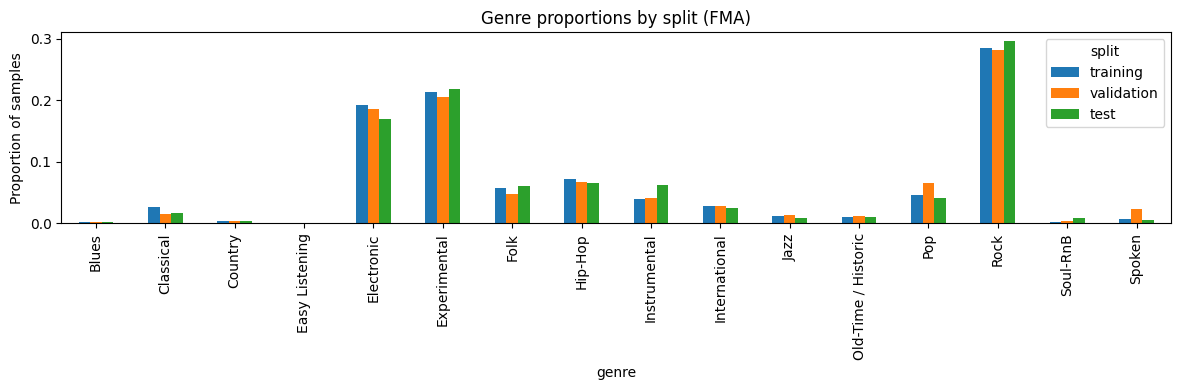


Drift ratios (closer to 1 is better):
                      test/train  val/train
genre                                     
Classical              0.656582   0.587797
Jazz                   0.820736   1.139523
Electronic             0.883421   0.965271
Hip-Hop                0.895483   0.930831
Spoken                 0.899631   3.482037
Pop                    0.906779   1.464337
International          0.918737   1.034970
Country                0.919101   0.967361
Old-Time / Historic    0.997127   1.030403
Experimental           1.022954   0.958581
Rock                   1.036603   0.986700
Folk                   1.060321   0.854727
Blues                  1.191814   0.868427
Instrumental           1.578789   1.027128
Soul-RnB               3.097406   1.516301
Easy Listening         3.227065   1.698257

TVD(train, val):  0.044093030272219544
TVD(train, test): 0.048814748857962845
JSD(train, val):  0.006750397359012998
JSD(train, test): 0.004856651814523141


In [3]:



# Keep only the columns we need
df = tracks[[("set","split"), ("track","genre_top")]].dropna()
df.columns = ["split", "genre"]

# 1) Counts and proportions
counts = pd.crosstab(df["genre"], df["split"]).sort_index()
props = counts / counts.sum(axis=0)

print("Counts:\n", counts)
print("\nProportions:\n", props)

# 2A) Plot proportions
ax = props[["training","validation","test"]].plot(kind="bar", figsize=(12,4))
ax.set_ylabel("Proportion of samples")
ax.set_title("Genre proportions by split (FMA)")
plt.tight_layout()
plt.show()

# 2B) Per-genre drift ratios (test/train, val/train)
drift = pd.DataFrame({
    "test/train": props["test"] / props["training"],
    "val/train":  props["validation"] / props["training"],
})
print("\nDrift ratios (closer to 1 is better):\n", drift.sort_values("test/train"))

# 2C) Distances: TVD and JSD
def tvd(p, q):
    return 0.5 * np.abs(p - q).sum()

def jsd(p, q, eps=1e-12):
    # Jensen-Shannon divergence (base 2)
    p = np.clip(p, eps, 1); p = p / p.sum()
    q = np.clip(q, eps, 1); q = q / q.sum()
    m = 0.5 * (p + q)
    kl_pm = np.sum(p * np.log2(p / m))
    kl_qm = np.sum(q * np.log2(q / m))
    return 0.5 * (kl_pm + kl_qm)

genres = props.index
p_train = props["training"].reindex(genres).fillna(0).to_numpy()
p_val   = props["validation"].reindex(genres).fillna(0).to_numpy()
p_test  = props["test"].reindex(genres).fillna(0).to_numpy()

print("\nTVD(train, val): ", tvd(p_train, p_val))
print("TVD(train, test):", tvd(p_train, p_test))
print("JSD(train, val): ", jsd(p_train, p_val))
print("JSD(train, test):", jsd(p_train, p_test))

In [4]:
from scipy.stats import entropy as scipy_entropy

# ── A) Split-level summary ────────────────────────────────────────────────────
total_tracks   = len(tracks)
labeled_tracks = len(df)
missing_labels = total_tracks - labeled_tracks

split_sizes = df["split"].value_counts().rename("labeled_tracks")
split_summary = pd.DataFrame(split_sizes)
split_summary.index.name = "split"
print("=" * 60)
print(f"Total tracks in CSV  : {total_tracks:,}")
print(f"Tracks with genre_top: {labeled_tracks:,}")
print(f"Missing genre_top    : {missing_labels:,} ({missing_labels/total_tracks:.1%})")
print()
print("Labeled tracks per split:")
print(split_summary.to_string())
print()

# ── B) Class-imbalance ratio per split ───────────────────────────────────────
print("=" * 60)
print("Class imbalance ratio (max_count / min_count) per split:")
for split in ["training", "validation", "test"]:
    col  = counts[split]
    ratio = col.max() / col.min()
    print(f"  {split:<12}: {col.max():>5} (max: {col.idxmax()}) / "
          f"{col.min():>4} (min: {col.idxmin()}) → ratio = {ratio:.1f}×")
print()

# ── C) Shannon entropy & effective number of classes per split ───────────────
print("=" * 60)
print("Shannon entropy & effective number of classes per split:")
print(f"  (max possible entropy for 16 classes = {np.log(len(counts)):.4f} nats)")
for split in ["training", "validation", "test"]:
    p    = counts[split] / counts[split].sum()
    h    = scipy_entropy(p)           # nats
    enc  = np.exp(h)                  # effective N classes
    print(f"  {split:<12}: H = {h:.4f} nats,  effective classes = {enc:.1f}")
print()

# ── D) Per-genre descriptive stats across splits ──────────────────────────────
print("=" * 60)
print("Per-genre count descriptives (mean / std / min / max across train+val+test):")
genre_stats = counts[["training", "validation", "test"]].agg(
    ["mean", "std", "min", "max"], axis=1
).round(1)
genre_stats.columns = ["mean", "std", "min", "max"]
genre_stats["cv%"] = (genre_stats["std"] / genre_stats["mean"] * 100).round(1)
genre_stats = genre_stats.sort_values("mean", ascending=False)
print(genre_stats.to_string())

Total tracks in CSV  : 106,574
Tracks with genre_top: 49,598
Missing genre_top    : 56,976 (53.5%)

Labeled tracks per split:
            labeled_tracks
split                     
training             39943
test                  4951
validation            4704

Class imbalance ratio (max_count / min_count) per split:
  training    : 11394 (max: Rock) /   15 (min: Easy Listening) → ratio = 759.6×
  validation  :  1324 (max: Rock) /    3 (min: Easy Listening) → ratio = 441.3×
  test        :  1464 (max: Rock) /    6 (min: Easy Listening) → ratio = 244.0×

Shannon entropy & effective number of classes per split:
  (max possible entropy for 16 classes = 2.7726 nats)
  training    : H = 2.0153 nats,  effective classes = 7.5
  validation  : H = 2.0622 nats,  effective classes = 7.9
  test        : H = 2.0228 nats,  effective classes = 7.6

Per-genre count descriptives (mean / std / min / max across train+val+test):
                       mean     std     min      max    cv%
genre            

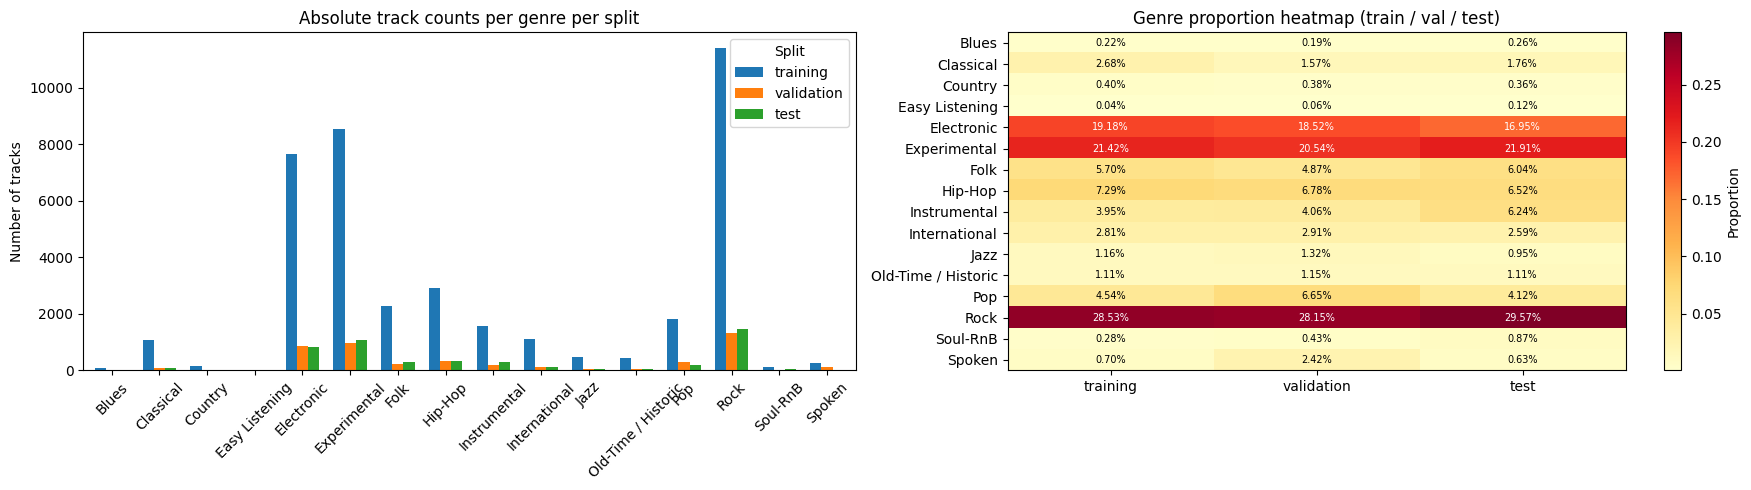

Chi-square test of homogeneity (are genre proportions the same?):
  Train vs Val  — χ²=216.83, dof=15, p=7.9051e-38
  Train vs Test — χ²=143.29, dof=15, p=5.1498e-23
  → Reject H₀: significant distribution difference detected.


In [5]:
import scipy.stats as scipy_stats

# ── 5A) Absolute-count bar chart ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

counts[["training", "validation", "test"]].plot(
    kind="bar", ax=axes[0], width=0.7
)
axes[0].set_title("Absolute track counts per genre per split")
axes[0].set_ylabel("Number of tracks")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(title="Split")

# ── 5B) Heatmap of proportions (genres × splits) ─────────────────────────────
heatmap_data = props[["training", "validation", "test"]]
im = axes[1].imshow(heatmap_data.values, aspect="auto", cmap="YlOrRd")
axes[1].set_xticks(range(len(heatmap_data.columns)))
axes[1].set_xticklabels(heatmap_data.columns)
axes[1].set_yticks(range(len(heatmap_data.index)))
axes[1].set_yticklabels(heatmap_data.index)
axes[1].set_title("Genre proportion heatmap (train / val / test)")
plt.colorbar(im, ax=axes[1], label="Proportion")

for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        val = heatmap_data.values[i, j]
        axes[1].text(j, i, f"{val:.2%}", ha="center", va="center", fontsize=7,
                     color="black" if val < 0.15 else "white")

plt.tight_layout()
plt.show()

# ── 5C) Chi-square test of homogeneity ───────────────────────────────────────
chi2_tv, p_tv, dof_tv, _ = scipy_stats.chi2_contingency(
    counts[["training", "validation"]].values
)
chi2_tt, p_tt, dof_tt, _ = scipy_stats.chi2_contingency(
    counts[["training", "test"]].values
)
print("Chi-square test of homogeneity (are genre proportions the same?):")
print(f"  Train vs Val  — χ²={chi2_tv:.2f}, dof={dof_tv}, p={p_tv:.4e}")
print(f"  Train vs Test — χ²={chi2_tt:.2f}, dof={dof_tt}, p={p_tt:.4e}")
if p_tv > 0.05 and p_tt > 0.05:
    print("  → Cannot reject H₀: distributions are statistically similar.")
else:
    print("  → Reject H₀: significant distribution difference detected.")

---

# Result Interpretation

## MelCNN MGR — Split Distribution Similarity Report (Train / Validation / Test)

### Context and purpose

This report integrates all computed metrics (counts, proportions, drift ratios, TVD/JSD, descriptive statistics, chi-square test) to evaluate whether the official FMA splits satisfy the project's "same distribution shape" assumption for training MelCNN MGR.

---

### 0) Dataset composition and split sizes

| | Value |
|---|---|
| Total tracks in CSV | **106,574** |
| Tracks with `genre_top` label | **49,598** (46.5%) |
| Missing `genre_top` | **56,976** (53.5% — unlabeled tracks outside the medium subset) |

| Split | Labeled tracks |
|---|---|
| training | **39,943** (80.5% of labeled) |
| validation | **4,704** (9.5%) |
| test | **4,951** (10.0%) |

**Interpretation:** The split is approximately a standard 80/10/10 train/val/test partition over labeled medium tracks. The 53.5% of rows with no `genre_top` are tracks outside the FMA-medium subset and are correctly excluded.

---

### 1) Class imbalance is severe — and consistent across splits

The per-split imbalance ratios (max genre count ÷ min genre count) are extremely large:

| Split | Max genre | Min genre | Ratio |
|---|---|---|---|
| training | Rock (11,394) | Easy Listening (15) | **759.6×** |
| validation | Rock (1,324) | Easy Listening (3) | **441.3×** |
| test | Rock (1,464) | Easy Listening (6) | **244.0×** |

Shannon entropy per split (max possible = **2.773 nats** for 16 uniform classes):

| Split | H (nats) | Effective classes |
|---|---|---|
| training | 2.015 | **7.5 / 16** |
| validation | 2.062 | **7.9 / 16** |
| test | 2.023 | **7.6 / 16** |

**Interpretation:** The effective number of classes is only about **7.5–7.9**, meaning the mass of the dataset behaves as if there were ~8 equally-weighted genres rather than 16. The imbalance is severe and consistent across splits, confirming that **accuracy is a misleading metric** — Macro-F1 and per-genre F1 are essential for this project.

---

### 2) Dominant genre proportions are stable across splits

For the three genres that dominate the dataset:

| Genre | Training | Validation | Test |
|---|---|---|---|
| Rock | 28.53% | 28.15% | 29.57% |
| Experimental | 21.42% | 20.54% | 21.91% |
| Electronic | 19.18% | 18.52% | 16.95% |

These three genres together account for ~69% of all labeled tracks and their proportions are consistent across splits, ensuring the core learning signal is well-represented everywhere.

---

### 3) Notable drift in minority genres

Drift ratio analysis (proportion in split ÷ proportion in training) flags several genres:

| Genre | test/train | val/train | Notable shift |
|---|---|---|---|
| Spoken | 0.90× | **3.48×** | 0.70% → 2.42% in validation |
| Easy Listening | **3.23×** | 1.70× | tiny absolute change (0.04% → 0.12%) |
| Soul-RnB | **3.10×** | 1.52× | 0.28% → 0.87% in test |
| Instrumental | **1.58×** | 1.03× | 3.95% → 6.24% in test |
| Pop | 0.91× | **1.46×** | 4.54% → 6.65% in validation |
| Classical | **0.66×** | **0.59×** | 2.68% → 1.76% test, 1.57% val |

**Interpretation:** The large ratios for Easy Listening and Soul-RnB are misleading — their absolute proportions are tiny (< 1%), making the ratio sensitive to a handful of tracks. The genuine operational shifts are **Spoken** (heavily over-represented in validation), **Instrumental** (over-represented in test), and **Classical** (under-represented in both val and test).

---

### 4) Global distance metrics confirm splits are operationally close

| Metric | Train vs Val | Train vs Test |
|---|---|---|
| TVD | **0.0441** | **0.0488** |
| JSD | **0.00675** | **0.00486** |

TVD ≈ 0.045–0.049 means only ~4.5–4.9% of probability mass would need to be redistributed across genres to make the splits identical — a small practical difference.

---

### 5) Chi-square test: statistically significant but driven by large n

| Comparison | χ² | dof | p-value |
|---|---|---|---|
| Train vs Val | 216.83 | 15 | 7.91 × 10⁻³⁸ |
| Train vs Test | 143.29 | 15 | 5.15 × 10⁻²³ |

Both tests **reject H₀** (distributions are the same), but this is **expected with n ≈ 40k** — the chi-square test is extremely sensitive to sample size and will flag even negligible differences as "significant" at this scale. The TVD (≈ 0.045) and JSD (≈ 0.005) are the practically meaningful measures and both indicate the splits are close.

---

### 6) Conclusion

The train/validation/test splits are **operationally similar** in genre distribution — the dominant genres (Rock, Experimental, Electronic) are consistent, global distance measures are small, and all three splits reflect the same severe class imbalance pattern. A few minority genres (Spoken, Instrumental, Classical) show moderate drift, but their absolute counts are small.

---

### Practical implications for MelCNN MGR

1. **Use the official FMA split** — it is well-structured, comparability and leakage-safety are preserved.
2. **Never use accuracy as the primary metric** — with 759× imbalance in training and only ~7.5 effective classes, accuracy will be driven almost entirely by Rock/Experimental/Electronic performance.
3. **Primary metrics:** Macro-F1 and per-genre F1. Report both.
4. **Class-weighted loss** is a well-motivated default given the severe imbalance; it is especially relevant for rare genres (Easy Listening, Soul-RnB, Blues, Country) where even small count shifts produce large drift ratios.
5. **Watch the Spoken / Instrumental / Classical genres** in validation and test respectively — per-genre F1 for these should be inspected separately to avoid misinterpreting aggregate results.